In [1]:
# Phase 4 — Marketing Strategy & Advanced Analysis
import pandas as pd
import numpy as np

# Load transaction-level data
tx = pd.read_csv("../data/online_retail.xlsx.csv", encoding="ISO-8859-1")

# Standardize columns to match earlier phases
tx.columns = (
    tx.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "")
)

tx['date'] = pd.to_datetime(tx['date'], errors='coerce')

if 'totalprice' not in tx.columns:
    tx['totalprice'] = pd.to_numeric(tx['quantity'], errors='coerce') * pd.to_numeric(tx['price'], errors='coerce')

# Load RFM with clusters (output from Phase 2–3)
rfm = pd.read_csv("../data/rfm_with_clusters.csv")

# Merge cluster labels back to transaction level
tx_cluster = tx.merge(
    rfm[['customerno', 'cluster']],
    on='customerno',
    how='inner'
)

tx_cluster.head()


,transactionno,date,productno,productname,price,quantity,customerno,country,totalprice,cluster
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,2
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,2
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,2
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80,2
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64,2


In [2]:
# Create a month column (year-month)
tx_cluster['month'] = tx_cluster['date'].dt.to_period('M').dt.to_timestamp()

monthly_revenue_cluster = (
    tx_cluster
    .groupby(['month', 'cluster'])['totalprice']
    .sum()
    .reset_index()
    .rename(columns={'totalprice': 'monthly_revenue'})
)

monthly_revenue_cluster.head()


,month,cluster,monthly_revenue
0,2018-12-01,0,128248.15
1,2018-12-01,1,247392.33
2,2018-12-01,2,2722697.79
3,2018-12-01,3,1144781.57
4,2019-01-01,0,81257.74


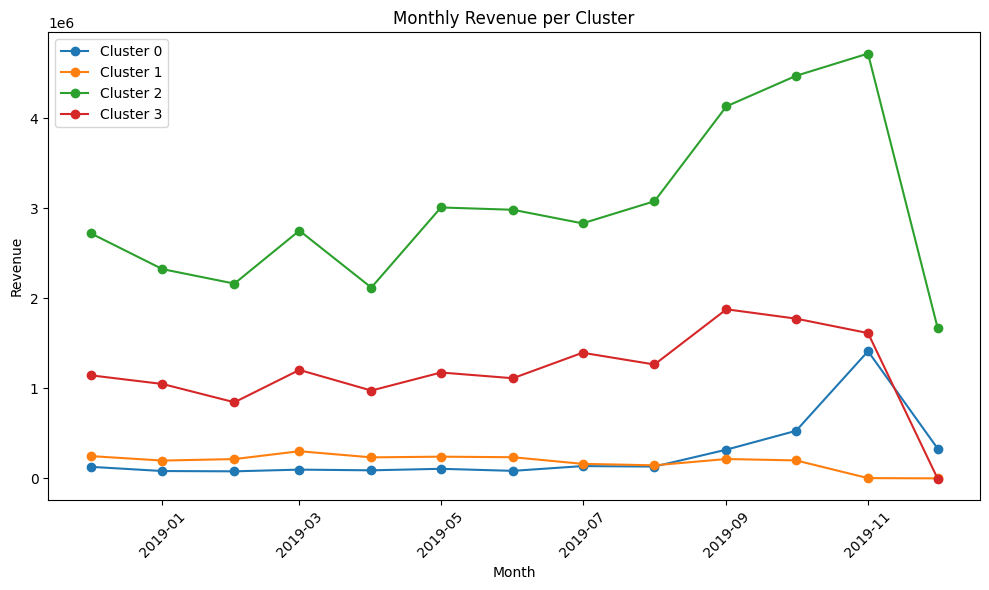

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for c in sorted(monthly_revenue_cluster['cluster'].unique()):
    subset = monthly_revenue_cluster[monthly_revenue_cluster['cluster'] == c]
    plt.plot(subset['month'], subset['monthly_revenue'], marker='o', label=f"Cluster {c}")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue per Cluster")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
monthly_active_customers = (
    tx_cluster
    .groupby(['month', 'cluster'])['customerno']
    .nunique()
    .reset_index()
    .rename(columns={'customerno': 'active_customers'})
)

monthly_active_customers.head()


,month,cluster,active_customers
0,2018-12-01,0,106
1,2018-12-01,1,203
2,2018-12-01,2,458
3,2018-12-01,3,305
4,2019-01-01,0,55


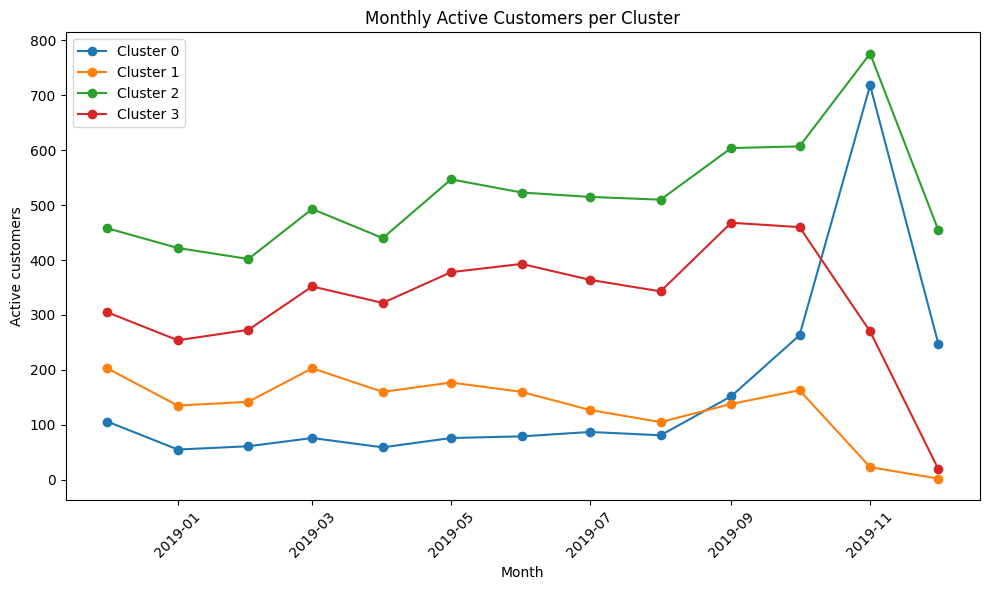

In [5]:
plt.figure(figsize=(10, 6))
for c in sorted(monthly_active_customers['cluster'].unique()):
    subset = monthly_active_customers[monthly_active_customers['cluster'] == c]
    plt.plot(subset['month'], subset['active_customers'], marker='o', label=f"Cluster {c}")

plt.xlabel("Month")
plt.ylabel("Active customers")
plt.title("Monthly Active Customers per Cluster")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# Customer-level view with country and cluster
cust_country = (
    tx_cluster
    .groupby(['customerno', 'country', 'cluster'])
    .size()
    .reset_index(name='tx_count')
)

cluster_country_counts = pd.crosstab(cust_country['cluster'], cust_country['country'])
cluster_country_counts.head()


country,Australia,Austria,Bahrain,Belgium,Brazil,Canada,Channel Islands,Cyprus,Czech Republic,Denmark,...,RSA,Saudi Arabia,Singapore,Spain,Sweden,Switzerland,USA,United Arab Emirates,United Kingdom,Unspecified
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,2,0,0,1,1,0,1,...,0,0,0,7,1,2,1,0,895,0
1,1,1,2,6,1,3,1,2,0,1,...,0,1,0,3,2,5,1,1,1305,2
2,3,1,0,5,0,0,1,0,0,1,...,0,0,0,4,3,1,1,0,839,0
3,5,3,0,9,0,1,4,3,1,6,...,1,0,1,9,1,13,1,1,1266,5


In [7]:
cluster_country_revenue = (
    tx_cluster
    .groupby(['cluster', 'country'])['totalprice']
    .sum()
    .reset_index()
)

# Calculate % share per cluster
cluster_country_revenue['revenue_share'] = (
    cluster_country_revenue
    .groupby('cluster')['totalprice']
    .transform(lambda x: 100 * x / x.sum())
)

cluster_country_revenue.head()


,cluster,country,totalprice,revenue_share
0,0,Austria,4112.90,0.116836
1,0,Belgium,7200.44,0.204545
2,0,Channel Islands,4651.50,0.132136
3,0,Cyprus,3535.27,0.100427
4,0,Denmark,1268.60,0.036037


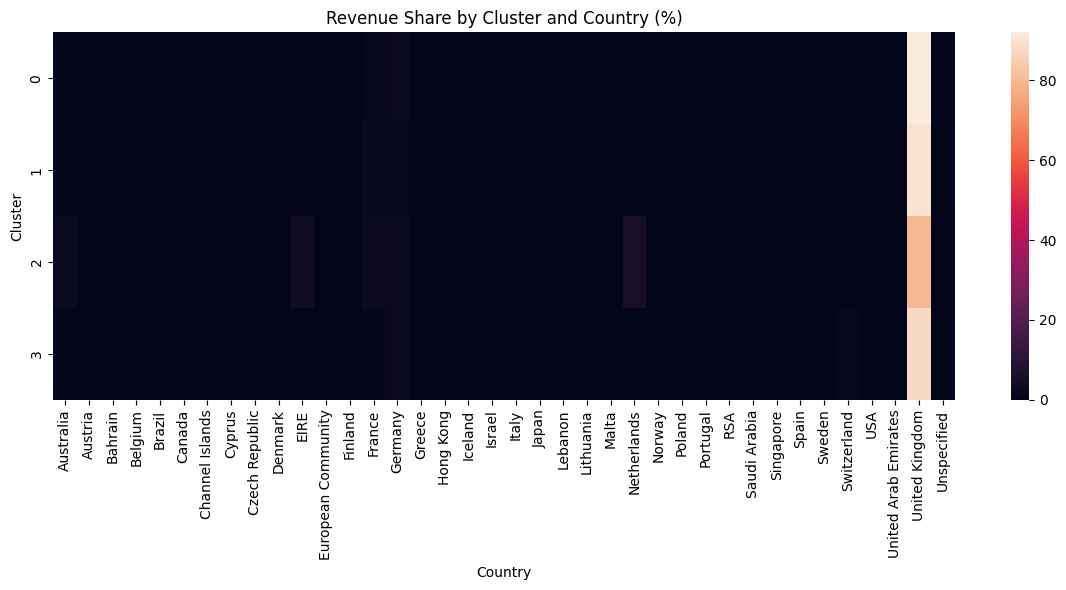

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_rev = cluster_country_revenue.pivot(index='cluster', columns='country', values='revenue_share').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_rev, annot=False)
plt.title("Revenue Share by Cluster and Country (%)")
plt.ylabel("Cluster")
plt.xlabel("Country")
plt.tight_layout()
plt.show()


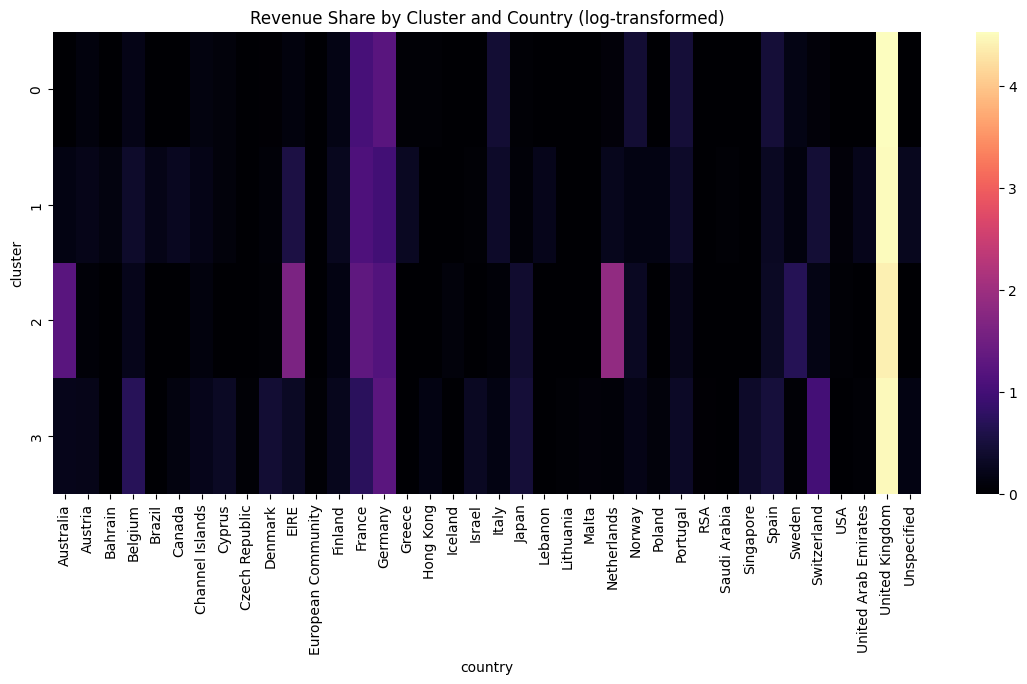

In [9]:
import numpy as np

pivot_log = np.log1p(pivot_rev)   # log(1+x)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_log, cmap='magma', annot=False)
plt.title("Revenue Share by Cluster and Country (log-transformed)")
plt.show()


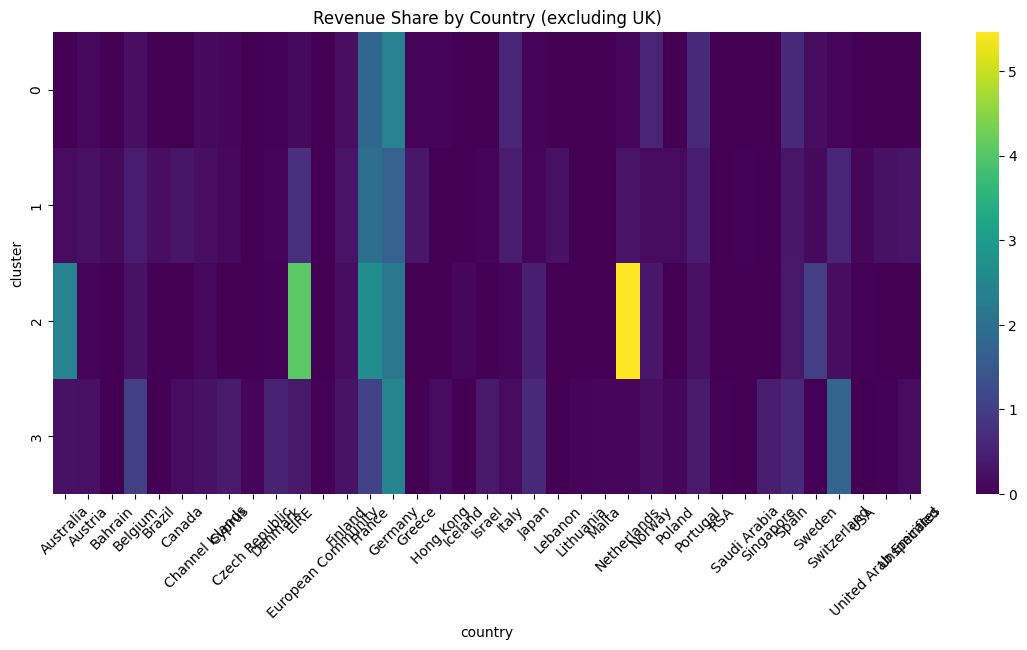

In [10]:
pivot_no_uk = pivot_rev.drop(columns=['United Kingdom'])

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_no_uk, cmap='viridis')
plt.title("Revenue Share by Country (excluding UK)")
plt.xticks(rotation=45)
plt.show()


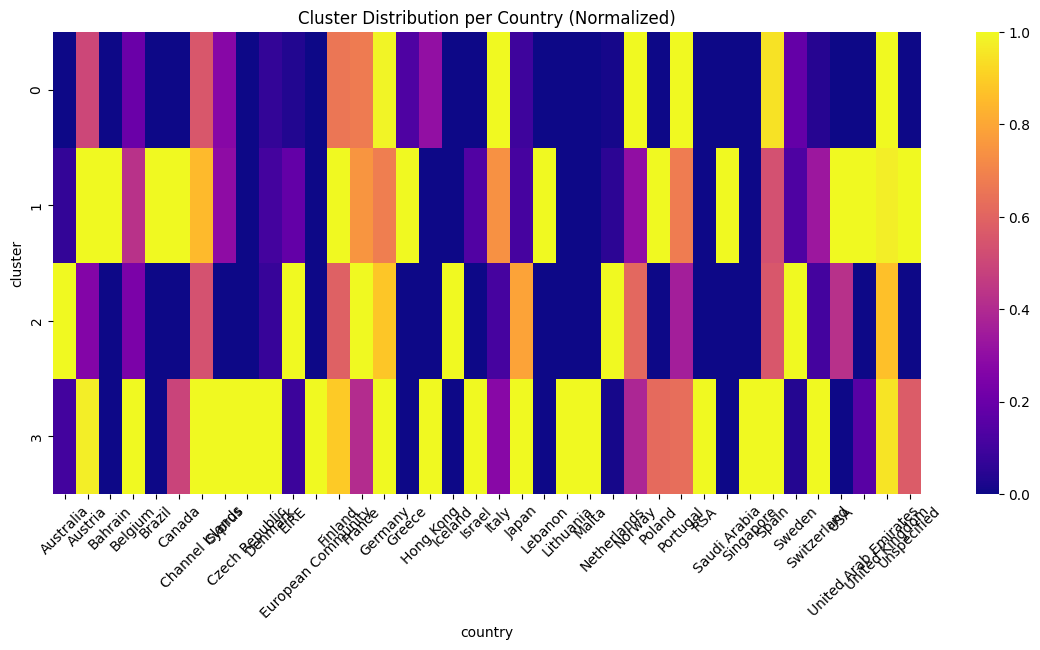

In [12]:
pivot_norm = pivot_rev.div(pivot_rev.max(axis=0), axis=1)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_norm, cmap='plasma')
plt.title("Cluster Distribution per Country (Normalized)")
plt.xticks(rotation=45)
plt.show()


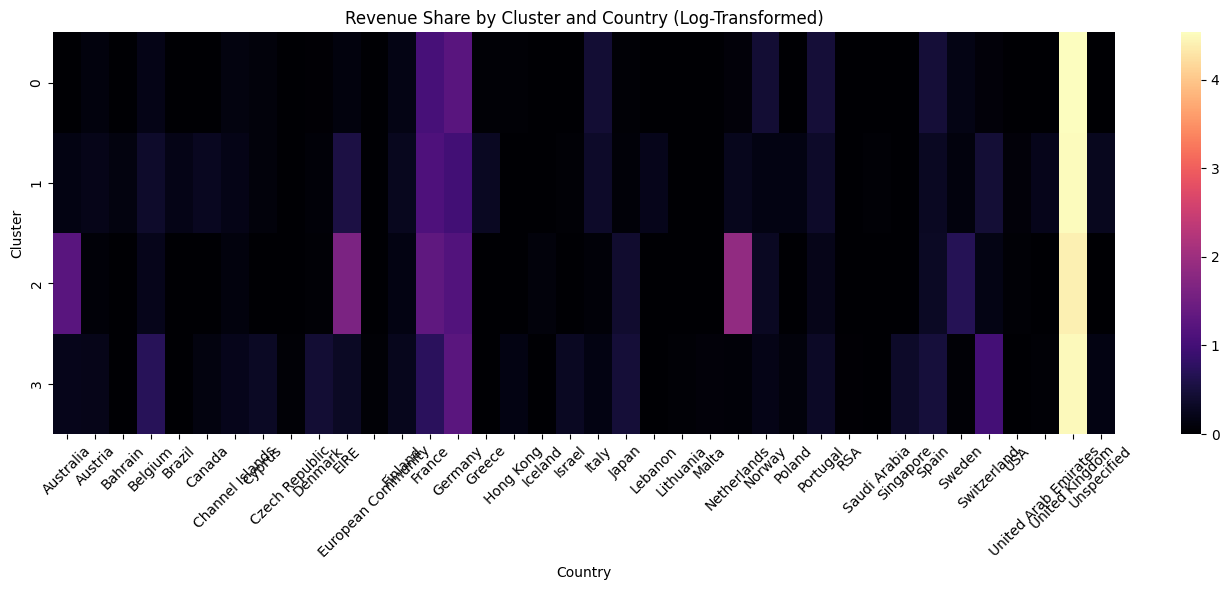

In [13]:
import numpy as np

pivot_log = np.log1p(pivot_rev)   # log(1 + x)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_log, cmap='magma', annot=False)
plt.title("Revenue Share by Cluster and Country (Log-Transformed)")
plt.xlabel("Country")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


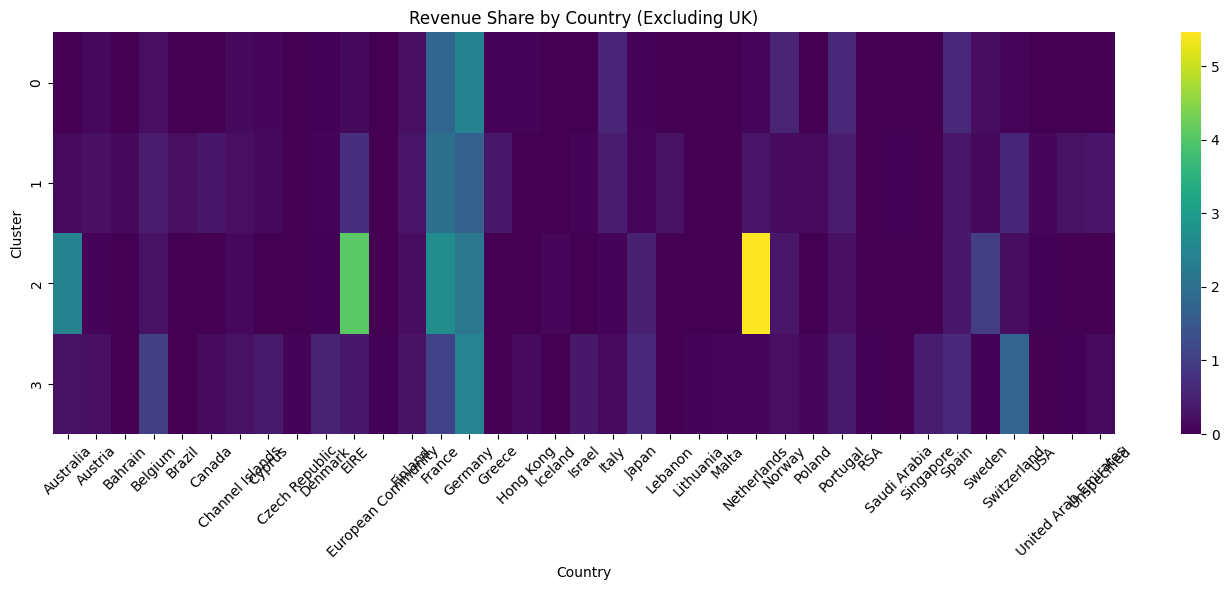

In [14]:
pivot_no_uk = pivot_rev.drop(columns=['United Kingdom'], errors='ignore')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_no_uk, cmap='viridis')
plt.title("Revenue Share by Country (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


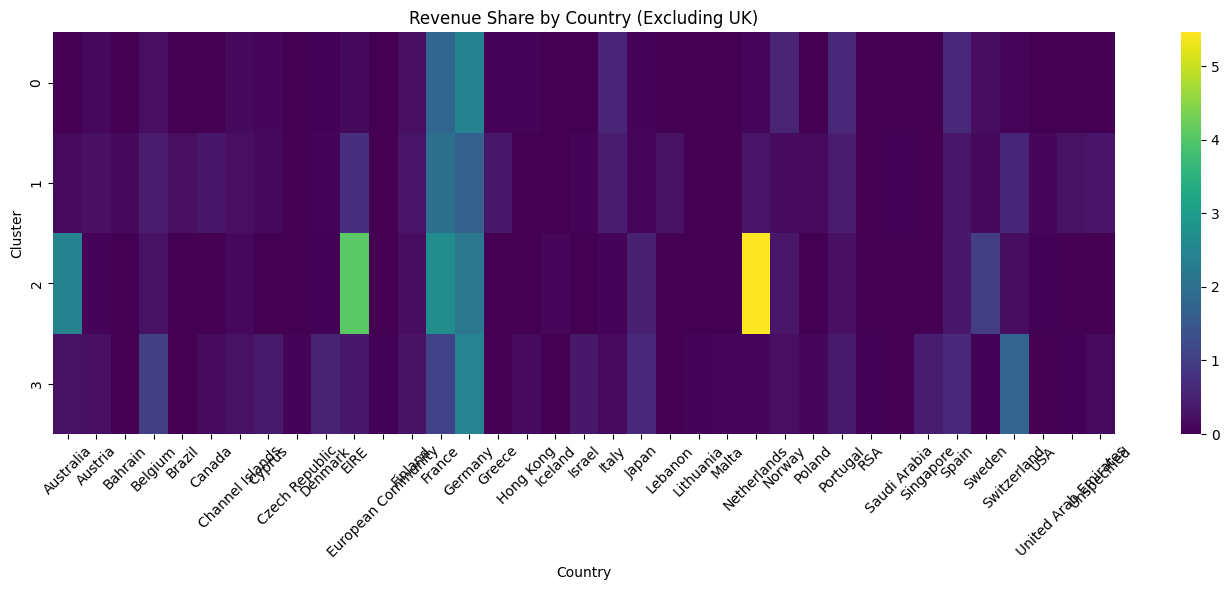

In [15]:
pivot_no_uk = pivot_rev.drop(columns=['United Kingdom'], errors='ignore')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_no_uk, cmap='viridis')
plt.title("Revenue Share by Country (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
country_rev = (
    tx_cluster.groupby(['cluster','country'])['totalprice']
    .sum()
    .reset_index()
)


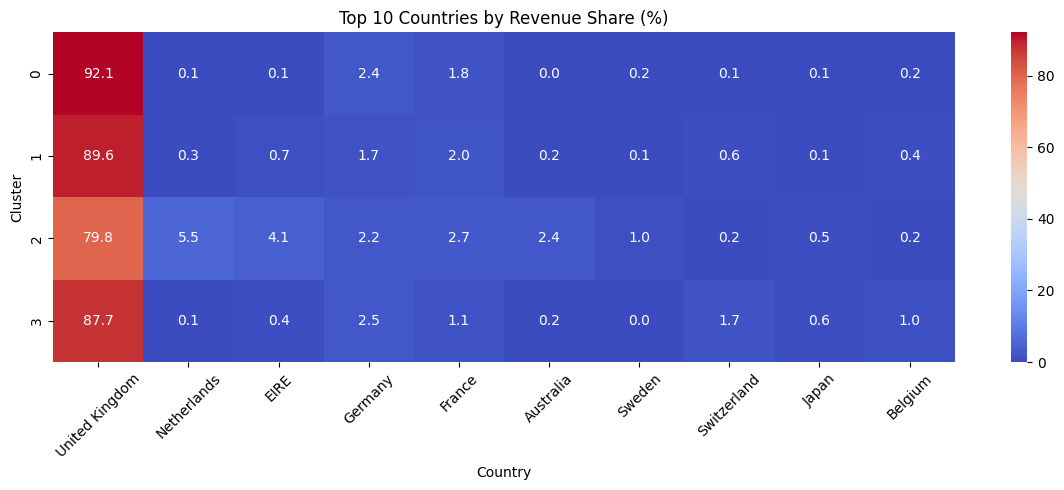

In [18]:
top_countries = (
    country_rev.groupby('country')['totalprice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

pivot_top = pivot_rev[top_countries]

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_top, cmap='coolwarm', annot=True, fmt='.1f')
plt.title("Top 10 Countries by Revenue Share (%)")
plt.xlabel("Country")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
country_total = (
    tx_cluster.groupby('country')['totalprice']
    .sum()
    .rename('country_revenue')
    .reset_index()
)


In [20]:
cluster_country_rev = (
    tx_cluster.groupby(['country','cluster'])['totalprice']
    .sum()
    .reset_index()
)

cluster_country_rev = cluster_country_rev.merge(country_total, on='country', how='left')
cluster_country_rev['share_in_country'] = 100 * cluster_country_rev['totalprice'] / cluster_country_rev['country_revenue']
cluster_country_rev.head()


,country,cluster,totalprice,country_revenue,share_in_country
0,Australia,1,4040.30,988756.35,0.408624
1,Australia,2,946431.95,988756.35,95.719431
2,Australia,3,38284.10,988756.35,3.871945
3,Austria,0,4112.90,68548.30,6.000003
4,Austria,1,5572.60,68548.30,8.129450


In [21]:
top_countries = (
    country_total.sort_values('country_revenue', ascending=False)
    .head(10)['country']
)

cc_top = cluster_country_rev[cluster_country_rev['country'].isin(top_countries)]


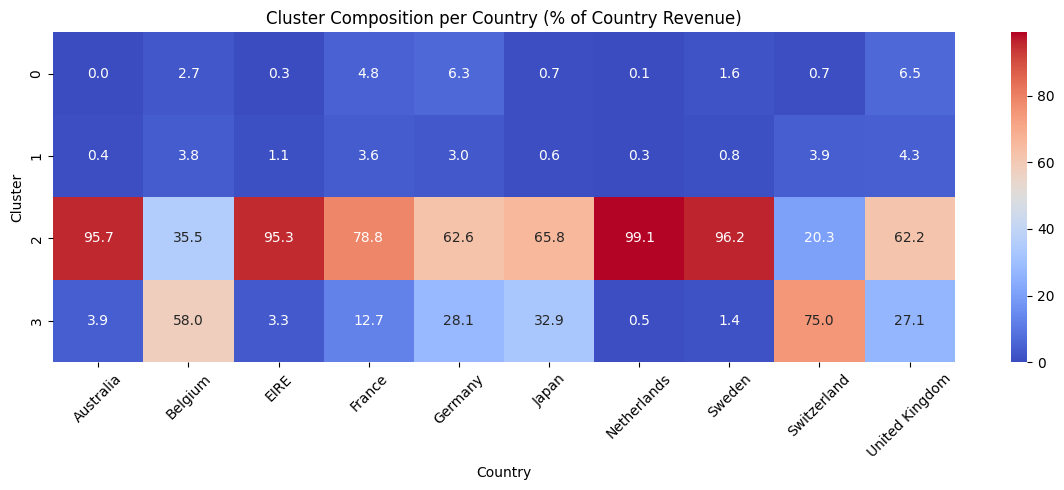

In [22]:
pivot_comp = cc_top.pivot(
    index='cluster',
    columns='country',
    values='share_in_country'
).fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_comp, cmap='coolwarm', annot=True, fmt='.1f')
plt.title("Cluster Composition per Country (% of Country Revenue)")
plt.xlabel("Country")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
